Files already downloaded and verified
Numero di classi nel dataset: 5749
[1,    10] loss: 8.786
Fine-tuning completato
Analizziamo l'immagine 25 con etichetta: Abdullah_Nasseef


/usr/local/lib/python3.10/dist-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(


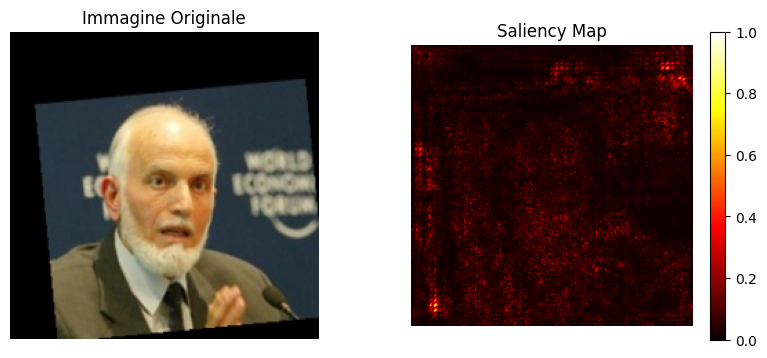

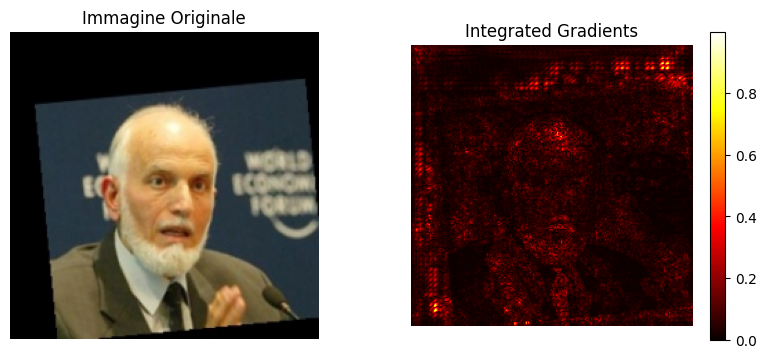

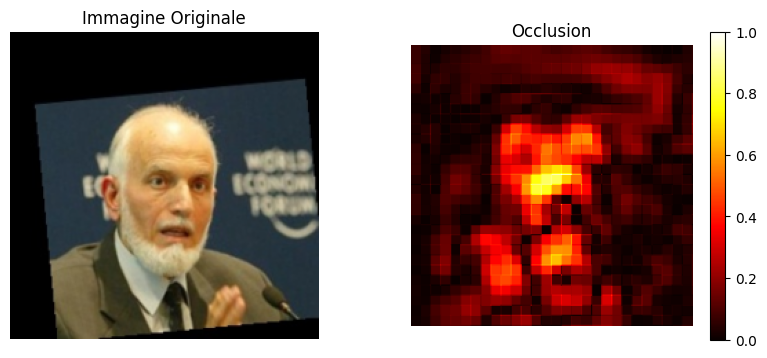

In [7]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import densenet121, DenseNet121_Weights
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from captum.attr import IntegratedGradients, Saliency, Occlusion
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup del modello e dataset
# Carichiamo DenseNet pre-addestrato
model = densenet121(weights=DenseNet121_Weights.DEFAULT)

# Trasformazioni per il dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # DenseNet si aspetta input 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])
])

# Carica il dataset Faces in the Wild
dataset = torchvision.datasets.LFWPeople(root='./data',
                                       split='train',
                                       transform=transform,
                                       download=True)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Freeziamo tutti i parametri della rete
for param in model.parameters():
    param.requires_grad = False

# Modifichiamo l'ultimo layer per il numero corretto di classi
num_classes = len(dataset.class_to_idx)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, num_classes)

print(f"Numero di classi nel dataset: {num_classes}")

# 2. Fine-tuning
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 1
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 10 == 9:    # stampa ogni 10 mini-batch
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 10:.3f}')
            running_loss = 0.0
            break

print('Fine-tuning completato')

# 3. Spiegazioni con Captum
model.eval()
face_idx = 25
input_img, label = dataset[face_idx]
input_img = input_img.unsqueeze(0).to(device)
label = torch.tensor([label]).to(device)

# Ottieni il nome della classe
class_names = list(dataset.class_to_idx.keys())
class_name = class_names[label.item()]
print(f"Analizziamo l'immagine {face_idx} con etichetta: {class_name}")

# Inizializzazione dei metodi di spiegazione
saliency = Saliency(model)
ig = IntegratedGradients(model)
occlusion = Occlusion(model)

def visualize_attributions(orig_img, attributions, title):
    attr_map = attributions.squeeze().cpu().detach().numpy()
    if len(attr_map.shape) > 2:
        attr_map = np.abs(attr_map).sum(axis=0)  # Somma sui canali

    # Normalizzazione
    attr_map = (attr_map - attr_map.min()) / (attr_map.max() - attr_map.min() + 1e-8)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    # Denormalizziamo l'immagine per la visualizzazione
    img_show = orig_img.squeeze().cpu().detach().numpy()
    img_show = np.transpose(img_show, (1, 2, 0))
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)

    plt.imshow(img_show)
    plt.title('Immagine Originale')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(attr_map, cmap='hot')
    plt.title(title)
    plt.axis('off')
    plt.colorbar()
    plt.show()

# Calcolo e visualizzazione delle attribuzioni
# Saliency
saliency_attr = saliency.attribute(input_img, target=label)
visualize_attributions(input_img, saliency_attr, 'Saliency Map')

# Integrated Gradients
ig_attr = ig.attribute(input_img, target=label, n_steps=50)
visualize_attributions(input_img, ig_attr, 'Integrated Gradients')

# Occlusion
occlusion_attr = occlusion.attribute(input_img,
                                   target=label,
                                   strides=(3, 8, 8),
                                   sliding_window_shapes=(3,15,15),
                                   baselines=0)
visualize_attributions(input_img, occlusion_attr, 'Occlusion')